Unsupervised Learning Project - Analysis of customer segments

In [5]:
#importing libraries
import pandas as pd
import numpy as np 
from som import SOM
from clustering import KmeansClustering

# reading data from csv
data=pd.read_csv("../data/customer_info_cleaned.csv")
data["customer_birthdate"] = pd.to_datetime(data["customer_birthdate"])

data_for_clustering=data.iloc[:,4:].copy()

data.head(10)

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,1970-02-12 13:36:00,0.0,0.0,0.0,0.0,-0.104564,0.973784,...,-0.396277,-0.176781,0.132530,0.271429,0.461538,1.130011,0.714286,0.0,1.455541,-1.730469
1,4,Bsc. Glenda Bauman,female,1975-11-13 18:58:00,0.0,-1.0,-1.0,-0.5,0.056867,-0.160139,...,-0.659574,1.575198,0.441767,1.609524,0.048951,-0.258072,-0.285714,0.0,0.108044,-0.671733
2,5,Msc. Antonio Campbell,male,1971-09-10 10:07:00,-1.0,-1.0,-0.8,-0.5,-0.048972,-0.464308,...,-0.316489,-0.236148,-0.489960,-0.500000,-0.293706,-0.490802,-1.428571,0.0,1.021787,-0.116230
3,7,John Kelling,male,1982-10-23 11:20:00,-1.0,-1.0,1.0,-1.0,-0.453084,-0.115287,...,0.760638,-0.265172,5.755020,-0.680952,-0.216783,0.040803,0.857143,0.0,-0.275625,0.234757
4,8,Arthur Dematteo,male,1969-08-04 22:22:00,-1.0,-1.0,2.0,-1.0,-0.313775,2.959886,...,0.670213,-0.513193,4.156627,0.542857,-0.818182,-0.152380,0.857143,0.0,-0.479940,-0.923065
5,9,Msc. Nadine Garcia,female,1968-10-09 04:01:00,0.0,0.0,0.0,1.5,0.290090,-0.099179,...,-0.578457,-0.228232,0.008032,-0.521905,-0.272727,-0.255895,-0.571429,0.0,-0.400908,-0.461078
6,10,Phd. Franklin Alba,male,1971-06-09 05:08:00,1.0,0.0,-1.0,-1.0,0.759663,0.876500,...,1.611702,0.263852,-0.080321,-0.990476,0.552448,0.103631,-0.142857,0.0,-0.566657,0.371212
7,11,Bsc. Robert Hansing,male,1977-07-19 10:22:00,0.0,0.0,0.0,1.5,1.378495,0.023057,...,0.292553,0.730871,6.530120,0.333333,0.398601,-0.216690,0.285714,0.0,-0.282584,-2.003222
8,12,Phd. Dorothy Pacheco,female,2000-05-19 03:02:00,-1.0,-1.0,-1.0,-0.5,-0.306044,-0.384081,...,0.115691,-0.017150,-0.610442,-1.252381,-0.657343,-1.067988,0.428571,0.0,0.010401,-0.324311
9,14,Msc. Arron Burgener,male,1948-11-28 19:53:00,0.0,-1.0,0.0,0.0,-0.412952,0.215098,...,-0.647606,0.932718,-0.180723,-1.128571,-0.461538,-0.121304,0.285714,0.0,1.278625,-0.804960


We will begin by clustering the data using Self Organized Maps.
We set the number of units to be 9 (3x3 grid).
We will run the algorithm for 150 epochs, then we will plot the component planes plot to see the "distribution"
of each feature in relation to the units (neurons/clusters).

In [ ]:
# we initialize a SOM object with a sigma of 1 (that will be used in the equation of "how far" two units are from each other),
# we initialize the learning rate to be 0.5, the dimensions are the amount of features, number of cluster=9,
# the range of the initial values of the units are within the [-1, 1] range. 
# we iterate the algorithm 150 times. The random seed we set to 7 (for results reproducability)
som = SOM(sigma=1, alpha=0.5, dimensions=21, k=9, low_range=-1, high_range=1, epochs=150, random_seed=7)
history = som.algorithm(data_for_clustering.values, data_for_clustering.columns)

som.plot_component_planes()

![alt text](../compplanesfinal.png)

From analysing the heat maps of our features, we can infer:

1) we see high values of spending on fish and meat across many clusters, meaning spending on fish and meat are not good candidates for 
differentiating between different customer segments.
2) In cluster number 7  i.e. [3, 1] we see extremely high concentration of video games spending as well as electronics spending,
    which makes sense - spending on video games and electronics may be correlated with each other. Cluster [3, 1] represent this particular group of costumers.
3) In cluster 1 i.e [1, 1] we see concentration of several features - including spenidng on drinks, petfood, meat.. but in particular we see very high concentration of the feature "kids at home". Meaning, cluster 1 represent the customers who have kids, are in the middle of their lives and they spend a lot on a veriety of groceries.
4) one more intersting observation is that in cluster 9 [3, 3] there is concentration of spending on vegetables as well as on hygiene.
This make sense - customers that care about their hygeine also care about heir health and they eat a lot of vegetables.
5) High Vegetables spending is concentrated in only one cluster.


Now we will move to analysis with Kmeans

In [ ]:
# we create a kmeansClustering object.
# for the testing we set minimum amount of clusters to be 2, maximum amount to be 15
# we will plot the elbow chart and the silhoette to determine the optimal amount k.
algorithm = KmeansClustering(min_k=2, max_k=15, data=data_for_clustering, random_seed=7)
algorithm.elbow_silhoette_plot(30)

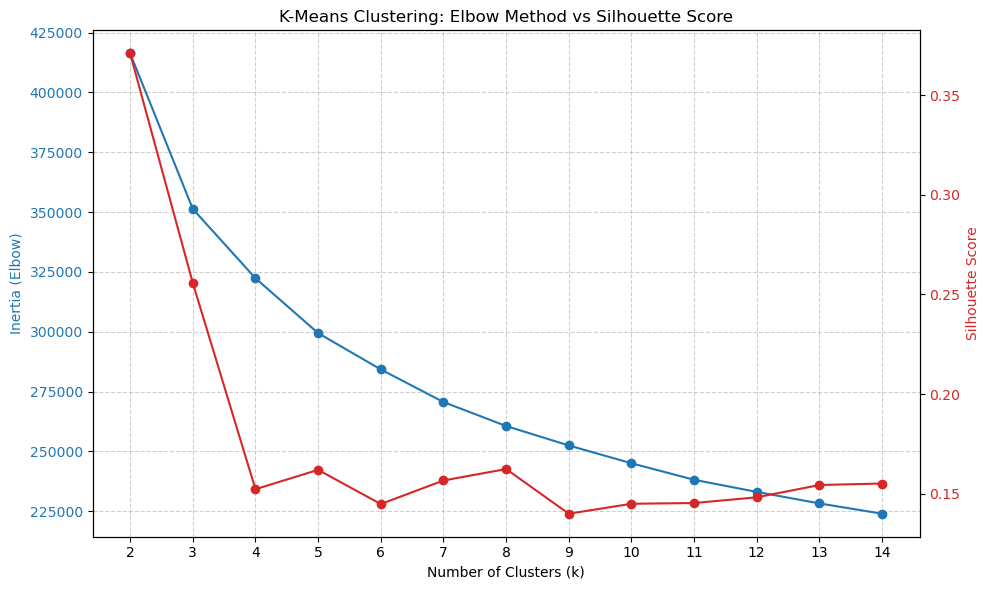

We are choosing k = 8

In [ ]:
labels, inertia, centroids = algorithm.cluster(k=8, epochs=30)
algorithm.plot_cluster_profiles(centroids, data_for_clustering.columns)

![alt text](../output_centroids.png)

Observations:
1) just like in SOM where one cluster represented customers who buy electronics as well as video games, 
we can see that cluster 1 has high values for electronics and video games with the video game spending being as high as 5.34.
2) cluster 4 - we see it has high values for kids and teens at home which represent the customers who have kids.
 cluster 4 also exhibits moderate values in several other features like spending on alcoholic drinks. 
3) cluster 2 exhibits moderate/high values for hygiene and vegetables spending.
4) cluster 7 has very low values almost for all features besides vegetables spending.

We see that there are similarities in the clustering results between SOM and Kmeans.
In both, the correlation between video games and electronics was shown, as well as a cluster of parents who spend on a veriety of products.

Business insights/suggestions based on the clustering results:

1) Target the electronics/gaming customer segment with early access video game promotions.
2) Target the parents segment with bundle deals - for instance, family portion groceries with wine discount to capture their broad spending habits.
3) Regarding the segment of costumers who spend a lot on vegetables (with low spending on other items) - do not waste marketing budget sending them meat ads or premium electronics. Target them with erlevent coupons.